# LEGO Brick Object Detection – Data Analysis

**CAS Deep Learning FS26 – CV Projekt**  
Marco Buri – 26.6.2026

## Problem Statement

Given synthetic (Blender-rendered) images containing multiple LEGO bricks, the goal is to **detect and classify** individual bricks by their part number.  
We work with a **subsample of 10 classes** drawn from the larger 600-class dataset.

- **Dataset:** `dataset_subsample_top10` — 10,115 images (600×600 px) with Pascal VOC XML annotations  
- **Classes:** The 10 most frequent LEGO part IDs from the original dataset  
- **Annotation note:** Objects belonging to non-target classes are kept in the XML but marked `difficult=1`, so training frameworks ignore them in loss/mAP computation while avoiding false-negative noise.

## Approach Overview

| Step | Model | Purpose |
|------|-------|---------|
| Baseline | ResNet-18 on cropped boxes | Verify classes are visually separable |
| Model A | Faster R-CNN (ResNet-50-FPN) | Two-stage detector, strong mAP |
| Model B | YOLOv8s | One-stage detector, speed/accuracy comparison |

Evaluation: mAP@50, mAP@50:95, inference time

## 1 · Setup & Imports

In [1]:
import os
import glob
import xml.etree.ElementTree as ET
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm.auto import tqdm

# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR = Path("data/dataset_subsample_top10")
ANN_DIR = BASE_DIR / "annotations"
IMG_DIR = BASE_DIR / "images"

ann_files = sorted(ANN_DIR.glob("*.xml"))
img_files = sorted(IMG_DIR.glob("*"))

print(f"Annotations: {len(ann_files):,}")
print(f"Images:      {len(img_files):,}")

Annotations: 10,115
Images:      10,115


/Users/marco/repos/cas-deep-learning-cv-projekt/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2 · Parse Annotations into DataFrame

Each Pascal VOC XML file contains one or more `<object>` elements. We parse every bounding box into a flat DataFrame, tracking the `difficult` flag to distinguish the 10 target classes from non-target objects.

In [ ]:
records = []
skipped = 0

for xml_path in tqdm(ann_files, desc="Parsing annotations"):
    try:
        tree = ET.parse(xml_path)
    except ET.ParseError:
        skipped += 1
        continue

    root = tree.getroot()
    size_el = root.find("size")
    if size_el is None:
        skipped += 1
        continue

    img_w = int(size_el.findtext("width", "0"))
    img_h = int(size_el.findtext("height", "0"))
    filename = root.findtext("filename", xml_path.stem + ".jpg")

    for obj in root.findall("object"):
        cls_name = obj.findtext("name", "unknown").strip()
        difficult = int(obj.findtext("difficult", "0"))
        box = obj.find("bndbox")
        if box is None:
            continue
        xmin = int(float(box.findtext("xmin", "0")))
        ymin = int(float(box.findtext("ymin", "0")))
        xmax = int(float(box.findtext("xmax", "0")))
        ymax = int(float(box.findtext("ymax", "0")))
        bw, bh = xmax - xmin, ymax - ymin

        records.append({
            "filename": filename,
            "img_width": img_w,
            "img_height": img_h,
            "class_name": cls_name,
            "difficult": difficult,
            "xmin": xmin, "ymin": ymin, "xmax": xmax, "ymax": ymax,
            "box_w": bw,
            "box_h": bh,
            "box_area": bw * bh,
            "aspect_ratio": bw / bh if bh > 0 else np.nan,
        })

df = pd.DataFrame(records)
target_classes = sorted(df.loc[df["difficult"] == 0, "class_name"].unique())

print(f"Total bounding boxes:  {len(df):,}")
print(f"  Target (difficult=0): {(df['difficult']==0).sum():,}")
print(f"  Non-target (diff=1):  {(df['difficult']==1).sum():,}")
print(f"Unique images:         {df['filename'].nunique():,}")
print(f"Skipped XMLs:          {skipped}")
print(f"\nTarget classes ({len(target_classes)}): {target_classes}")
df.head(10)

Parsing annotations: 100%|██████████| 10115/10115 [00:01<00:00, 8281.73it/s]

Total bounding boxes:  35,992
  Target (difficult=0): 10,353
  Background (diff=1):  25,639
Unique images:         10,115
Skipped XMLs:          0

Target classes (10): ['15332', '24246', '30028', '30165', '3622', '60471', '63869', '63965', '64782', '76766']


,filename,img_width,img_height,class_name,difficult,xmin,ymin,xmax,ymax,box_w,box_h,box_area,aspect_ratio
0,00002cc0-e4b9-11eb-afd8-b0c090bd3910.jpg,600,600,3023,1,0,77,59,169,59,92,5428,0.641304
1,00002cc0-e4b9-11eb-afd8-b0c090bd3910.jpg,600,600,32140,1,212,41,397,137,185,96,17760,1.927083
2,00002cc0-e4b9-11eb-afd8-b0c090bd3910.jpg,600,600,60471,0,481,431,600,550,119,119,14161,1.000000
3,00002cc0-e4b9-11eb-afd8-b0c090bd3910.jpg,600,600,34103,1,348,371,441,538,93,167,15531,0.556886
4,0002651c-e4a0-11eb-bd6b-b0c090bd3910.jpg,600,600,61482,1,568,55,600,143,32,88,2816,0.363636
5,0002651c-e4a0-11eb-bd6b-b0c090bd3910.jpg,600,600,3297,1,0,322,185,526,185,204,37740,0.906863
6,0002651c-e4a0-11eb-bd6b-b0c090bd3910.jpg,600,600,30165,0,96,157,193,255,97,98,9506,0.989796
7,0002651c-e4a0-11eb-bd6b-b0c090bd3910.jpg,600,600,39739,1,345,101,390,143,45,42,1890,1.071429
8,0009ace4-e79d-11eb-9afd-b0c090bd3910.jpg,300,300,4589,1,225,0,265,61,40,61,2440,0.655738
9,0009ace4-e79d-11eb-9afd-b0c090bd3910.jpg,300,300,30165,0,56,130,244,300,188,170,31960,1.105882


## 3 · High-level Summary Statistics

In [ ]:
# ── Per-image statistics ──────────────────────────────────────────────────────
img_stats = df.groupby("filename").agg(
    total_objects=("class_name", "size"),
    target_objects=("difficult", lambda x: (x == 0).sum()),
    nt_objects=("difficult", lambda x: (x == 1).sum()),
    img_w=("img_width", "first"),
    img_h=("img_height", "first"),
).reset_index()

summary = pd.DataFrame({
    "Metric": [
        "Total images",
        "Total bounding boxes",
        "  ↳ target (difficult=0)",
        "  ↳ non-target (difficult=1)",
        "Unique target classes",
        "Unique non-target classes",
        "Image sizes (W×H)",
        "Avg objects/image (total)",
        "Avg target objects/image",
    ],
    "Value": [
        f"{img_stats.shape[0]:,}",
        f"{len(df):,}",
        f"{(df['difficult']==0).sum():,}",
        f"{(df['difficult']==1).sum():,}",
        str(len(target_classes)),
        str(df.loc[df["difficult"]==1, "class_name"].nunique()),
        f"{img_stats['img_w'].unique()} × {img_stats['img_h'].unique()}",
        f"{img_stats['total_objects'].mean():.1f}",
        f"{img_stats['target_objects'].mean():.1f}",
    ]
})
display(summary)

,Metric,Value
0,Total images,"10,115"
1,Total bounding boxes,"35,992"
2,↳ target (difficult=0),"10,353"
3,↳ background (difficult=1),"25,639"
4,Unique target classes,10
5,Unique background classes,564
6,Image sizes (W×H),[600 300] × [600 300]
7,Avg objects/image (total),3.6
8,Avg target objects/image,1.0


## 4 · Target Class Distribution

Distribution of bounding boxes across the 10 target classes (only `difficult=0`).

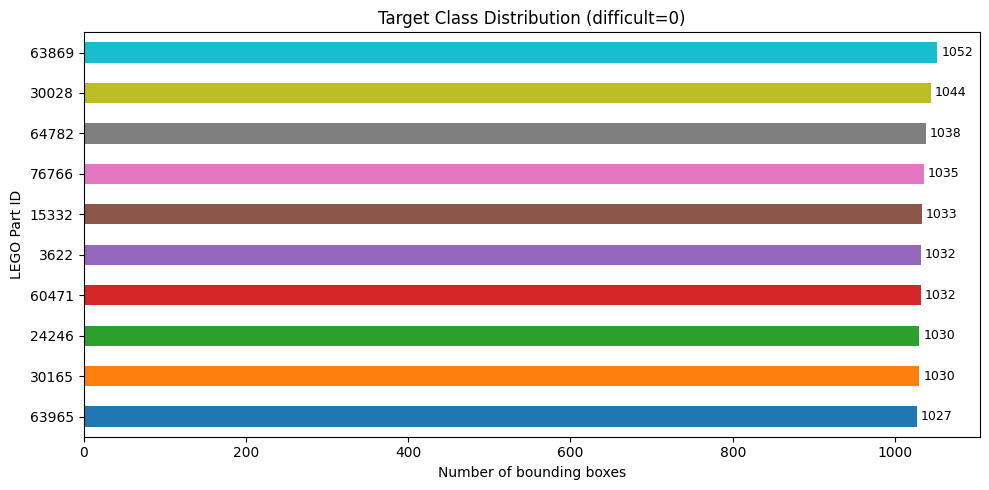

Min: 1027, Max: 1052, Ratio max/min: 1.02
→ Classes are very well balanced.


In [5]:
df_target = df[df["difficult"] == 0].copy()

counts = df_target["class_name"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(counts)))
counts.plot(kind="barh", ax=ax, color=colors, edgecolor="none")
ax.set_xlabel("Number of bounding boxes")
ax.set_ylabel("LEGO Part ID")
ax.set_title("Target Class Distribution (difficult=0)")
for i, (cls, cnt) in enumerate(counts.items()):
    ax.text(cnt + 5, i, str(cnt), va="center", fontsize=9)
plt.tight_layout()
plt.show()

# Class balance ratio
print(f"Min: {counts.min()}, Max: {counts.max()}, "
      f"Ratio max/min: {counts.max()/counts.min():.2f}")
print("→ Classes are very well balanced.")

## 5 · Objects per Image Distribution

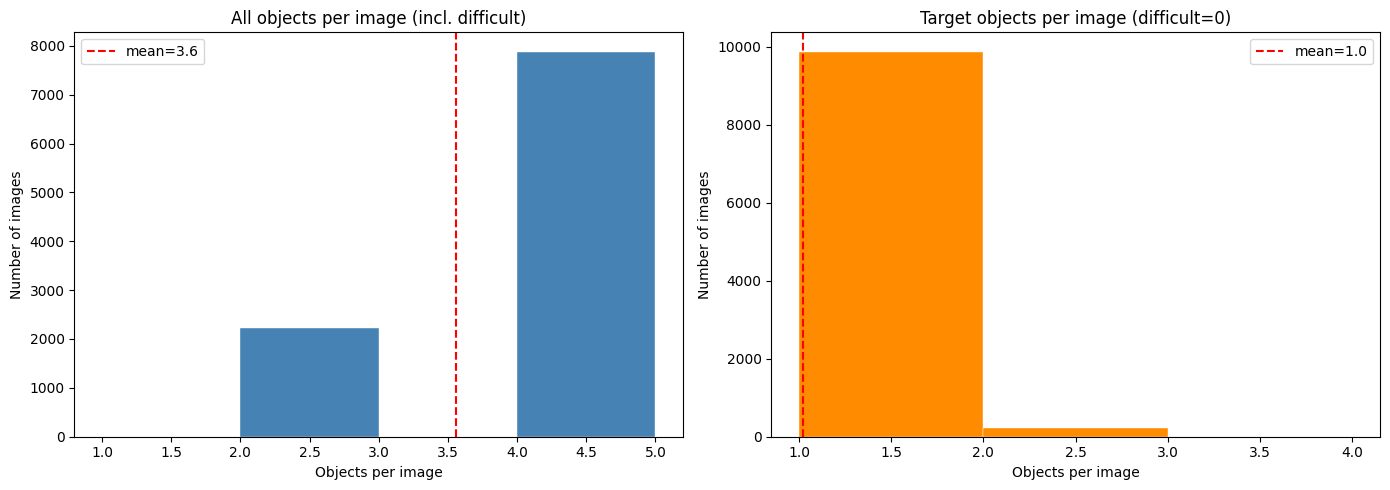

Total objects/image:  min=2, median=4, max=4
Target objects/image: min=1, median=1, max=3


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total objects per image (target + non-target)
total_per_img = df.groupby("filename").size()
axes[0].hist(total_per_img, bins=range(1, total_per_img.max() + 2),
             color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].axvline(total_per_img.mean(), color="red", ls="--",
                label=f"mean={total_per_img.mean():.1f}")
axes[0].set_title("All objects per image (incl. non-target)")
axes[0].set_xlabel("Objects per image")
axes[0].set_ylabel("Number of images")
axes[0].legend()

# Target objects per image
target_per_img = df_target.groupby("filename").size()
axes[1].hist(target_per_img, bins=range(1, target_per_img.max() + 2),
             color="darkorange", edgecolor="white", linewidth=0.3)
axes[1].axvline(target_per_img.mean(), color="red", ls="--",
                label=f"mean={target_per_img.mean():.1f}")
axes[1].set_title("Target objects per image (difficult=0)")
axes[1].set_xlabel("Objects per image")
axes[1].set_ylabel("Number of images")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Total objects/image:  min={total_per_img.min()}, "
      f"median={total_per_img.median():.0f}, max={total_per_img.max()}")
print(f"Target objects/image: min={target_per_img.min()}, "
      f"median={target_per_img.median():.0f}, max={target_per_img.max()}")

## 6 · Bounding Box Geometry Analysis

Width, height, area, and aspect ratio distributions of target bounding boxes.

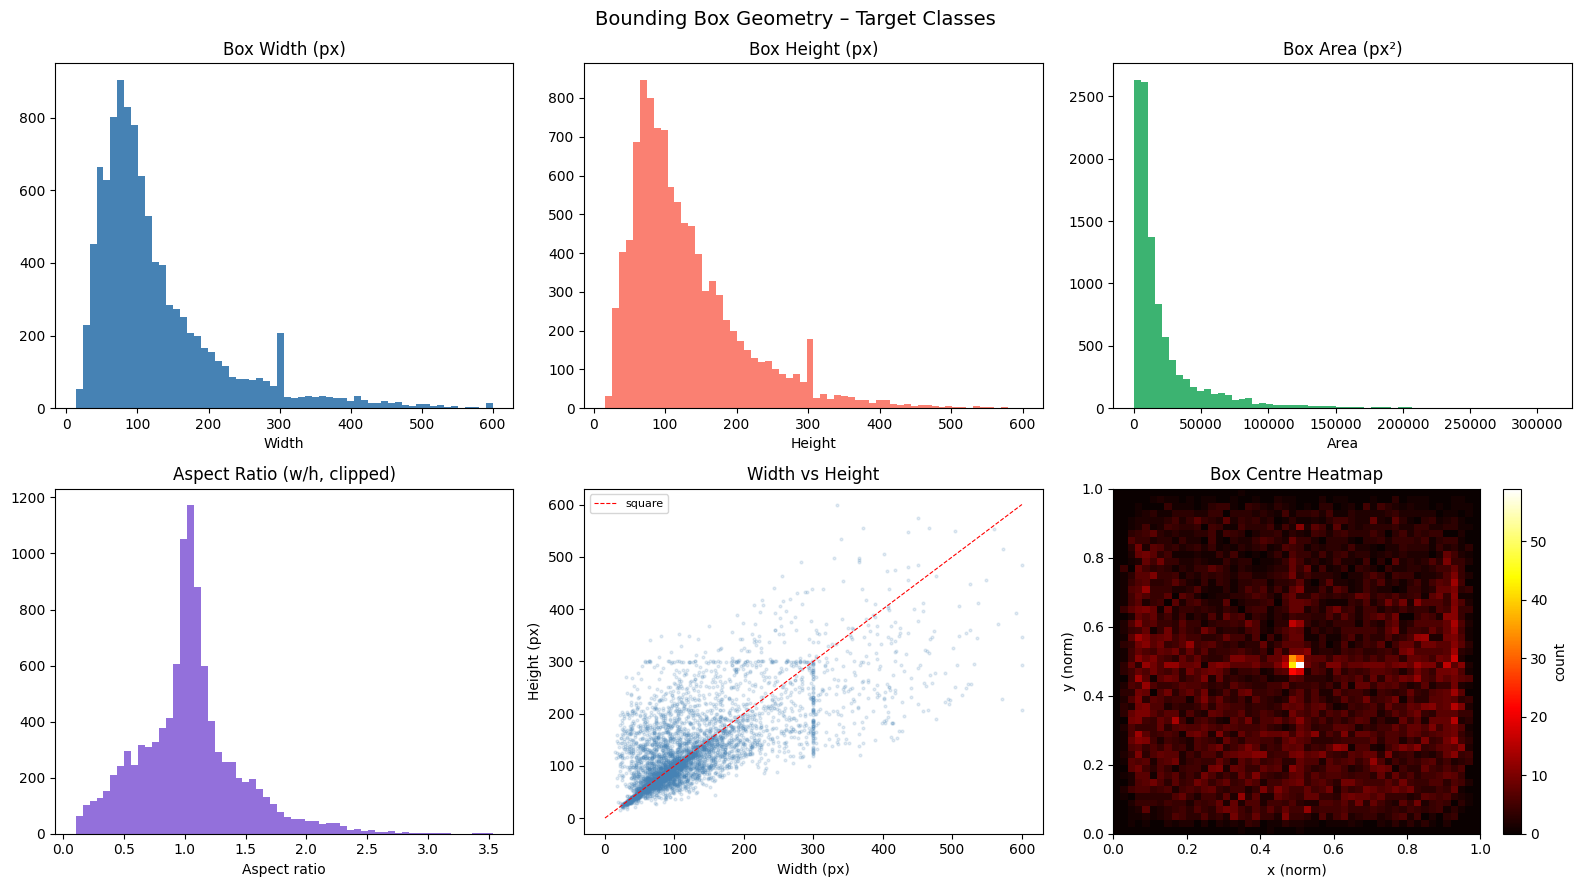


Box statistics (target classes):
         box_w    box_h  box_area  aspect_ratio
count  10353.0  10353.0   10353.0       10353.0
mean     127.6    130.5   21771.7           1.0
std       90.6     80.7   30966.3           0.4
min       13.0     16.0     336.0           0.1
25%       69.0     74.0    5440.0           0.8
50%       99.0    108.0   10481.0           1.0
75%      156.0    165.0   23482.0           1.2
max      600.0    599.0  310240.0           3.5


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0, 0].hist(df_target["box_w"], bins=60, color="steelblue", edgecolor="none")
axes[0, 0].set_title("Box Width (px)")
axes[0, 0].set_xlabel("Width")

axes[0, 1].hist(df_target["box_h"], bins=60, color="salmon", edgecolor="none")
axes[0, 1].set_title("Box Height (px)")
axes[0, 1].set_xlabel("Height")

axes[0, 2].hist(df_target["box_area"], bins=60, color="mediumseagreen", edgecolor="none")
axes[0, 2].set_title("Box Area (px²)")
axes[0, 2].set_xlabel("Area")

axes[1, 0].hist(df_target["aspect_ratio"].clip(0, 5), bins=60,
                color="mediumpurple", edgecolor="none")
axes[1, 0].set_title("Aspect Ratio (w/h, clipped)")
axes[1, 0].set_xlabel("Aspect ratio")

# Width vs Height scatter
sample = df_target.sample(min(5000, len(df_target)), random_state=42)
axes[1, 1].scatter(sample["box_w"], sample["box_h"], alpha=0.15, s=4, color="steelblue")
axes[1, 1].plot([0, 600], [0, 600], "r--", lw=0.8, label="square")
axes[1, 1].set_title("Width vs Height")
axes[1, 1].set_xlabel("Width (px)")
axes[1, 1].set_ylabel("Height (px)")
axes[1, 1].legend(fontsize=8)

# BBox centre heatmap (normalised coords)
cx = (df_target["xmin"] + df_target["box_w"] / 2) / df_target["img_width"]
cy = (df_target["ymin"] + df_target["box_h"] / 2) / df_target["img_height"]
h2d, xe, ye = np.histogram2d(cx, cy, bins=50, range=[[0, 1], [0, 1]])
im = axes[1, 2].imshow(h2d.T, origin="lower", aspect="auto",
                        extent=[0, 1, 0, 1], cmap="hot")
axes[1, 2].set_title("Box Centre Heatmap")
axes[1, 2].set_xlabel("x (norm)")
axes[1, 2].set_ylabel("y (norm)")
plt.colorbar(im, ax=axes[1, 2], label="count")

plt.suptitle("Bounding Box Geometry – Target Classes", fontsize=14)
plt.tight_layout()
plt.show()

print("\nBox statistics (target classes):")
print(df_target[["box_w", "box_h", "box_area", "aspect_ratio"]].describe().round(1))

## 7 · Per-Class Box Size Comparison

Box area distribution per target class — useful to check whether certain parts are systematically larger or smaller.

/var/folders/x6/14c83b8s1hb1tjyh7vzz2s7m0000gn/T/ipykernel_63996/903076188.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_area, vert=False, labels=order, patch_artist=True,
/var/folders/x6/14c83b8s1hb1tjyh7vzz2s7m0000gn/T/ipykernel_63996/903076188.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(data_ar, vert=False, labels=order, patch_artist=True,


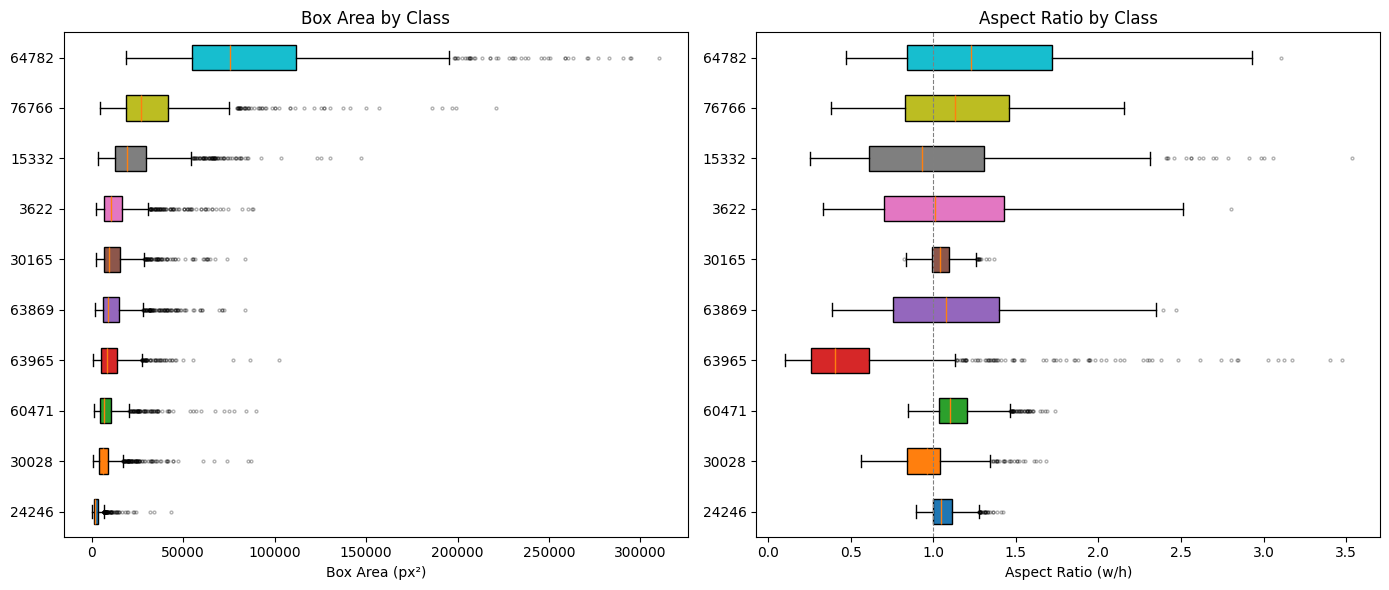

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

order = df_target.groupby("class_name")["box_area"].median().sort_values().index

# Box area boxplot
data_area = [df_target.loc[df_target["class_name"] == c, "box_area"].values for c in order]
bp = axes[0].boxplot(data_area, vert=False, tick_labels=order, patch_artist=True,
                     flierprops=dict(markersize=2, alpha=0.3))
for patch, color in zip(bp["boxes"], plt.cm.tab10(np.linspace(0, 1, len(order)))):
    patch.set_facecolor(color)
axes[0].set_xlabel("Box Area (px²)")
axes[0].set_title("Box Area by Class")

# Aspect ratio boxplot
data_ar = [df_target.loc[df_target["class_name"] == c, "aspect_ratio"].dropna().values
           for c in order]
bp2 = axes[1].boxplot(data_ar, vert=False, tick_labels=order, patch_artist=True,
                      flierprops=dict(markersize=2, alpha=0.3))
for patch, color in zip(bp2["boxes"], plt.cm.tab10(np.linspace(0, 1, len(order)))):
    patch.set_facecolor(color)
axes[1].set_xlabel("Aspect Ratio (w/h)")
axes[1].set_title("Aspect Ratio by Class")
axes[1].axvline(1.0, color="gray", ls="--", lw=0.8)

plt.tight_layout()
plt.show()

## 8 · Sample Images with Bounding Boxes

Random sample of images with annotations drawn. **Green** = target class, **red** = non-target (difficult=1).

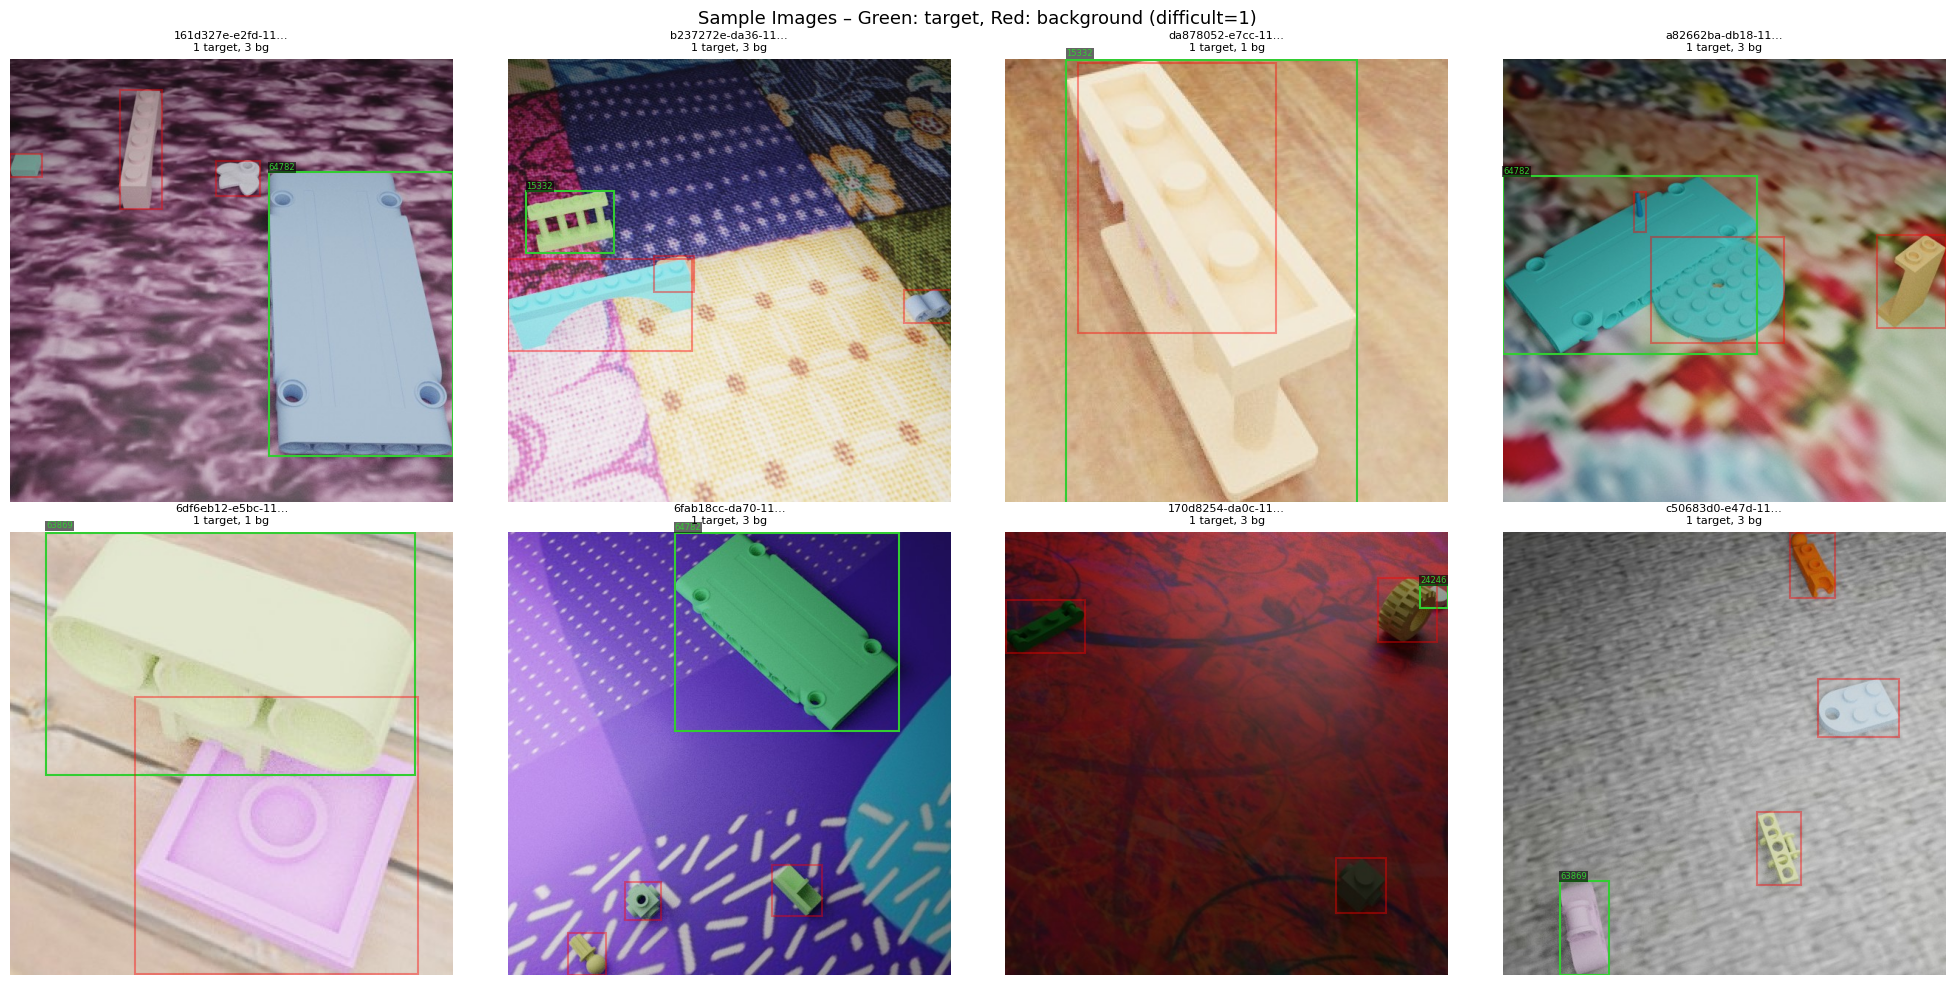

In [ ]:
rng = np.random.default_rng(42)
N_SAMPLES = 8

all_filenames = df["filename"].unique()
chosen = rng.choice(all_filenames, size=min(N_SAMPLES, len(all_filenames)), replace=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for ax, fname in zip(axes.flatten(), chosen):
    img_path = IMG_DIR / fname
    if not img_path.exists():
        ax.set_title(f"{fname}\n(not found)")
        ax.axis("off")
        continue

    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.axis("off")

    rows = df[df["filename"] == fname]
    n_target = (rows["difficult"] == 0).sum()
    n_nt = (rows["difficult"] == 1).sum()
    ax.set_title(f"{Path(fname).stem[:16]}…\n{n_target} target, {n_nt} non-target", fontsize=8)

    for _, r in rows.iterrows():
        color = "limegreen" if r["difficult"] == 0 else "red"
        alpha = 1.0 if r["difficult"] == 0 else 0.4
        rect = mpatches.FancyBboxPatch(
            (r["xmin"], r["ymin"]), r["box_w"], r["box_h"],
            linewidth=1.5, edgecolor=color, facecolor="none", alpha=alpha,
            boxstyle="square,pad=0"
        )
        ax.add_patch(rect)
        if r["difficult"] == 0:
            ax.text(r["xmin"], r["ymin"] - 3, r["class_name"],
                    fontsize=6, color=color,
                    bbox=dict(boxstyle="square,pad=0.1", fc="black", alpha=0.6, lw=0))

plt.suptitle("Sample Images – Green: target, Red: non-target (difficult=1)", fontsize=13)
plt.tight_layout()
plt.show()